# Dupire Delta Hedge vs Neural-Network Delta Hedge

This notebook runs the project's main results pipeline and compares two hedge strategies on the same short-call portfolio.

- **Dupire Delta Hedge:** uses an educational local-volatility delta proxy.
- **Neural-Network Delta Hedge:** predicts option delta directly from market features.

Run `gen_dat.ipynb` first. This notebook requires `data/historical_options.csv`, which is generated from the SPY options archive, so the comparison uses real historical option data rather than synthetic fallback data.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

from config import CONFIG
from src.backtest import run_hedge_backtest
from src.data_loader import load_all_data
from src.dupire import compute_dupire_delta_for_options, compute_local_vol_surface
from src.features import add_market_features
from src.metrics import compare_strategies
from src.nn_hedge import prepare_nn_dataset, predict_nn_delta, train_nn_hedge_model
from src.plots import create_strategy_plots, plot_volatility_surfaces
from src.portfolio import select_backtest_portfolio
from src.utils import ensure_directories, set_random_seeds

ensure_directories()
set_random_seeds(CONFIG.random_seed)
pd.set_option("display.max_columns", None)

## 1. Load Data

This step loads the real archive-generated historical option data. If `data/historical_options.csv` is missing, the notebook stops instead of falling back to synthetic data.


In [2]:
stock, surface_options, historical_options, mode = load_all_data(CONFIG)

if mode != "historical_csv":
    raise RuntimeError(
        "Real historical options were not loaded. Run gen_dat.ipynb first so "
        "data/historical_options.csv exists, then restart this notebook."
    )
print(f"Data mode: {mode}")
print(f"Stock rows: {len(stock):,}")
print(f"Surface option rows: {len(surface_options):,}")
print(f"Backtest option rows: {len(historical_options):,}")

surface_options.to_csv("data/surface_options.csv", index=False)
historical_options.to_csv("data/backtest_options.csv", index=False)
historical_options.head()

Loading cached stock prices from data/spy_stock_prices.csv.
Data mode: historical_csv
Stock rows: 332
Surface option rows: 1,575
Backtest option rows: 4,066,220


,date,expiration,underlying_price,strike,bid,ask,lastPrice,impliedVolatility,volume,delta,gamma,vega,theta,option_type,openInterest,mid_price,T,moneyness,log_moneyness,days_to_expiry,bid_ask_spread,relative_spread
0,2010-01-04,2010-01-15,113.29,91.0,22.20,22.40,21.32,0.68850,2.0,0.93661,0.00076,0.02065,-0.00985,call,1,22.300,0.030137,0.803248,-0.219091,11,0.20,0.008969
1,2010-01-04,2010-01-15,113.29,92.0,21.20,21.41,20.83,0.65040,0.0,0.93863,0.00085,0.02050,-0.01049,call,1,21.305,0.030137,0.812075,-0.208162,11,0.21,0.009857
2,2010-01-04,2010-01-15,113.29,93.0,20.26,20.45,16.65,0.63800,0.0,0.93777,0.00216,0.02139,-0.05566,call,1,20.355,0.030137,0.820902,-0.197351,11,0.19,0.009334
3,2010-01-04,2010-01-15,113.29,94.0,19.25,19.44,19.39,0.60232,3.0,0.93809,0.00241,0.02151,-0.05169,call,1,19.345,0.030137,0.829729,-0.186656,11,0.19,0.009822
4,2010-01-04,2010-01-15,113.29,95.0,18.24,18.45,18.24,0.56766,1.0,0.93924,0.00274,0.02155,-0.04883,call,1,18.345,0.030137,0.838556,-0.176074,11,0.21,0.011447


## 2. Fit the Dupire-Inspired Local-Volatility Surface

In [3]:
local_vol_model = compute_local_vol_surface(surface_options, CONFIG.risk_free_rate)
plot_volatility_surfaces(surface_options, local_vol_model)

print(
    f"Local volatility range: {local_vol_model.local_vol_grid.min():.4f} "
    f"to {local_vol_model.local_vol_grid.max():.4f}"
)

Local volatility range: 0.0100 to 2.0000


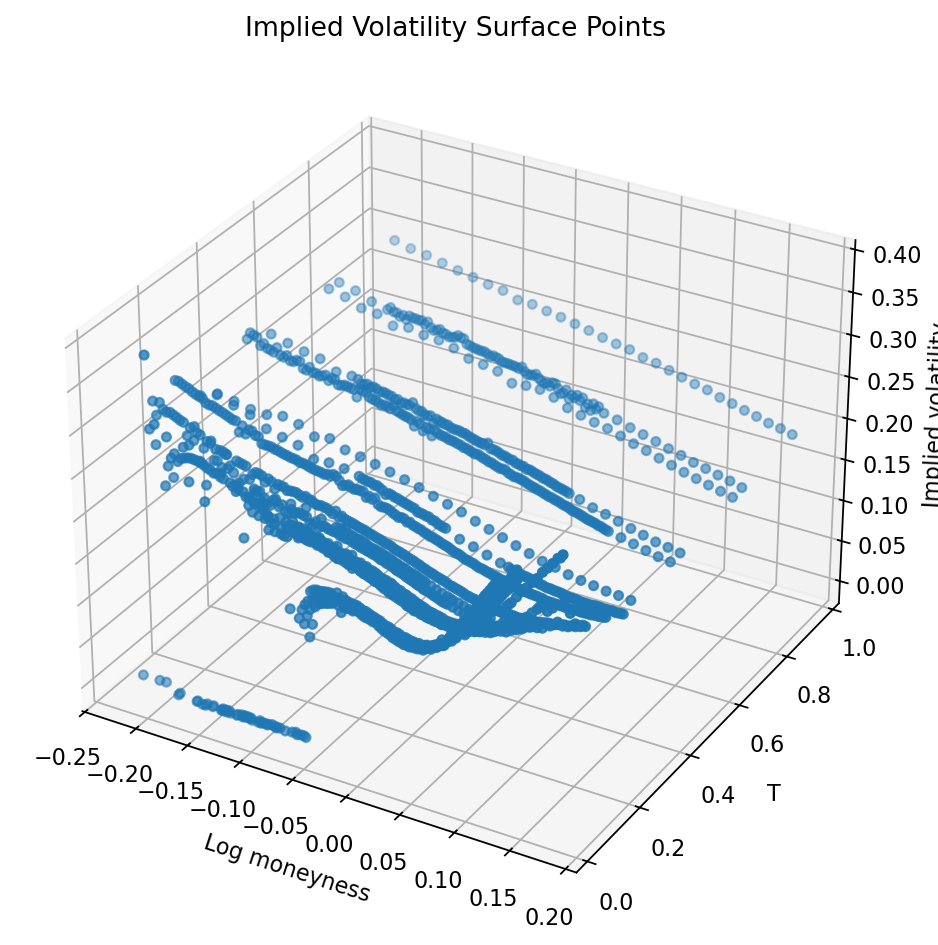

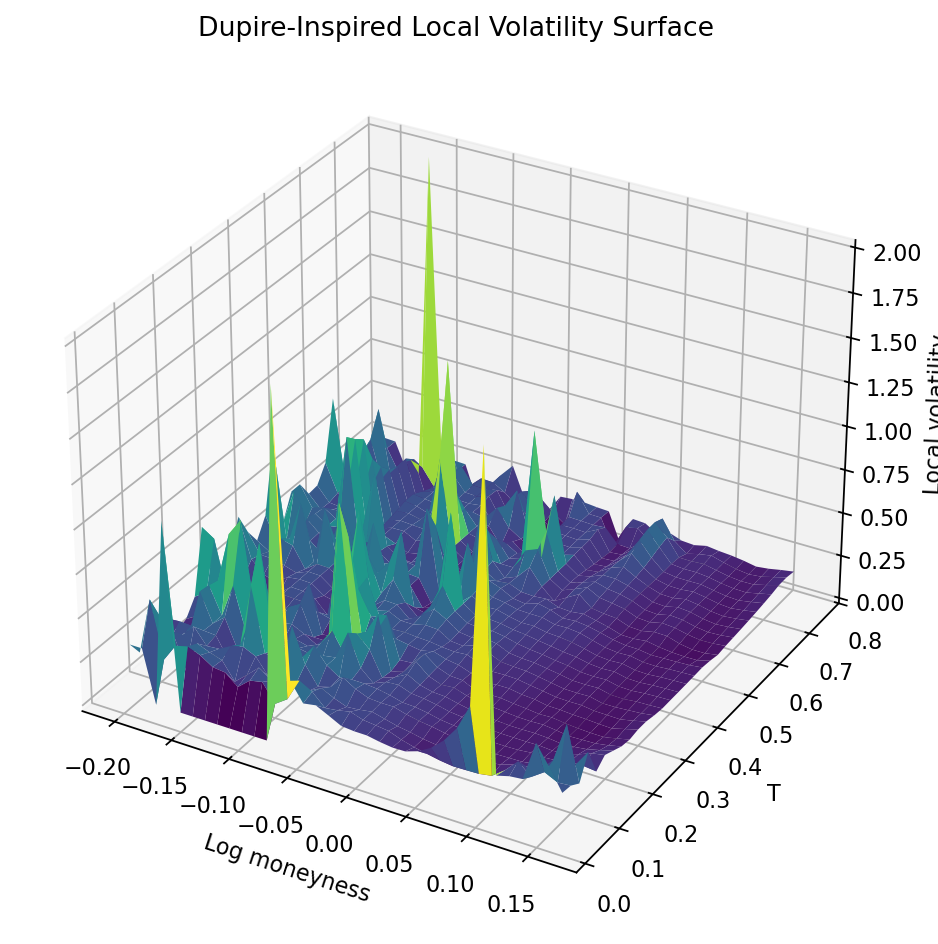

In [4]:
display(Image(filename="results/plots/implied_volatility_surface.png"))
display(Image(filename="results/plots/local_volatility_surface.png"))

## 3. Prepare and Train the Neural-Network Hedge

When repeated historical contract observations exist, the target is realized next-period delta. Otherwise, the code clearly warns that it is using a proxy target.

In [5]:
nn_dataset = prepare_nn_dataset(historical_options, stock, CONFIG.risk_free_rate)
nn_dataset.to_csv("data/nn_training_dataset.csv", index=False)

model, scaler, test_start_date = train_nn_hedge_model(
    nn_dataset,
    epochs=CONFIG.nn_epochs,
    learning_rate=CONFIG.nn_learning_rate,
    patience=CONFIG.nn_patience,
    random_seed=CONFIG.random_seed,
)
print(f"Out-of-sample test period begins: {pd.Timestamp(test_start_date).date()}")

NN early stopping after 168 epochs.
Out-of-sample test period begins: 2022-10-04


## 4. Build the Shared Out-of-Sample Portfolio

In [6]:
featured_options = add_market_features(historical_options, stock, CONFIG.risk_free_rate)
featured_options = compute_dupire_delta_for_options(
    featured_options, CONFIG.risk_free_rate, local_vol_model
)

out_of_sample_features = featured_options[
    featured_options["date"] >= pd.Timestamp(test_start_date)
].copy()

if len(out_of_sample_features) < 5:
    raise ValueError(
        "Fewer than five out-of-sample option rows remain. "
        "Use a longer date range or check the train/test split."
    )

portfolio = select_backtest_portfolio(out_of_sample_features, CONFIG.portfolio_type)
portfolio["nn_delta"] = predict_nn_delta(model, scaler, portfolio)
portfolio.to_csv("data/out_of_sample_portfolio.csv", index=False)

print(f"Out-of-sample portfolio dates: {len(portfolio):,}")
portfolio[["date", "underlying_price", "mid_price", "dupire_delta", "nn_delta"]].head()


Out-of-sample portfolio dates: 63


,date,underlying_price,mid_price,dupire_delta,nn_delta
0,2022-10-04,377.80,33.015,0.596985,0.447393
1,2022-10-05,377.12,32.415,0.574882,0.480504
2,2022-10-06,373.21,31.115,0.545689,0.411806
3,2022-10-07,362.91,25.135,0.510230,0.351953
4,2022-10-10,360.07,24.120,0.491638,0.385424


## 5. Run Both Hedge Strategies

In [7]:
dupire_result = run_hedge_backtest(
    portfolio, "dupire_delta", "Dupire Delta Hedge", CONFIG
)
nn_result = run_hedge_backtest(
    portfolio, "nn_delta", "Neural-Network Delta Hedge", CONFIG
)

dupire_result.to_csv("results/dupire_backtest.csv", index=False)
nn_result.to_csv("results/nn_backtest.csv", index=False)
create_strategy_plots(dupire_result, nn_result)

## 6. Main Results

In [8]:
comparison = compare_strategies(dupire_result, nn_result)
comparison.to_csv("results/strategy_comparison.csv", index=False)
comparison.style.format({column: "{:.4f}" for column in comparison.columns if column != "model"})

,model,final_value,total_pnl,mean_daily_pnl,pnl_volatility,sharpe,mean_abs_hedging_error,rmse_hedging_error,max_drawdown,transaction_costs,turnover
0,Dupire Delta Hedge,-3012.5149,291.2405,4.6229,44.2000,1.6603,34.6057,44.0909,-248.8163,8.1689,213.6898
1,Neural-Network Delta Hedge,-3005.8562,297.3341,4.7196,101.1306,0.7408,74.1832,100.4357,-676.9620,10.8952,283.1709


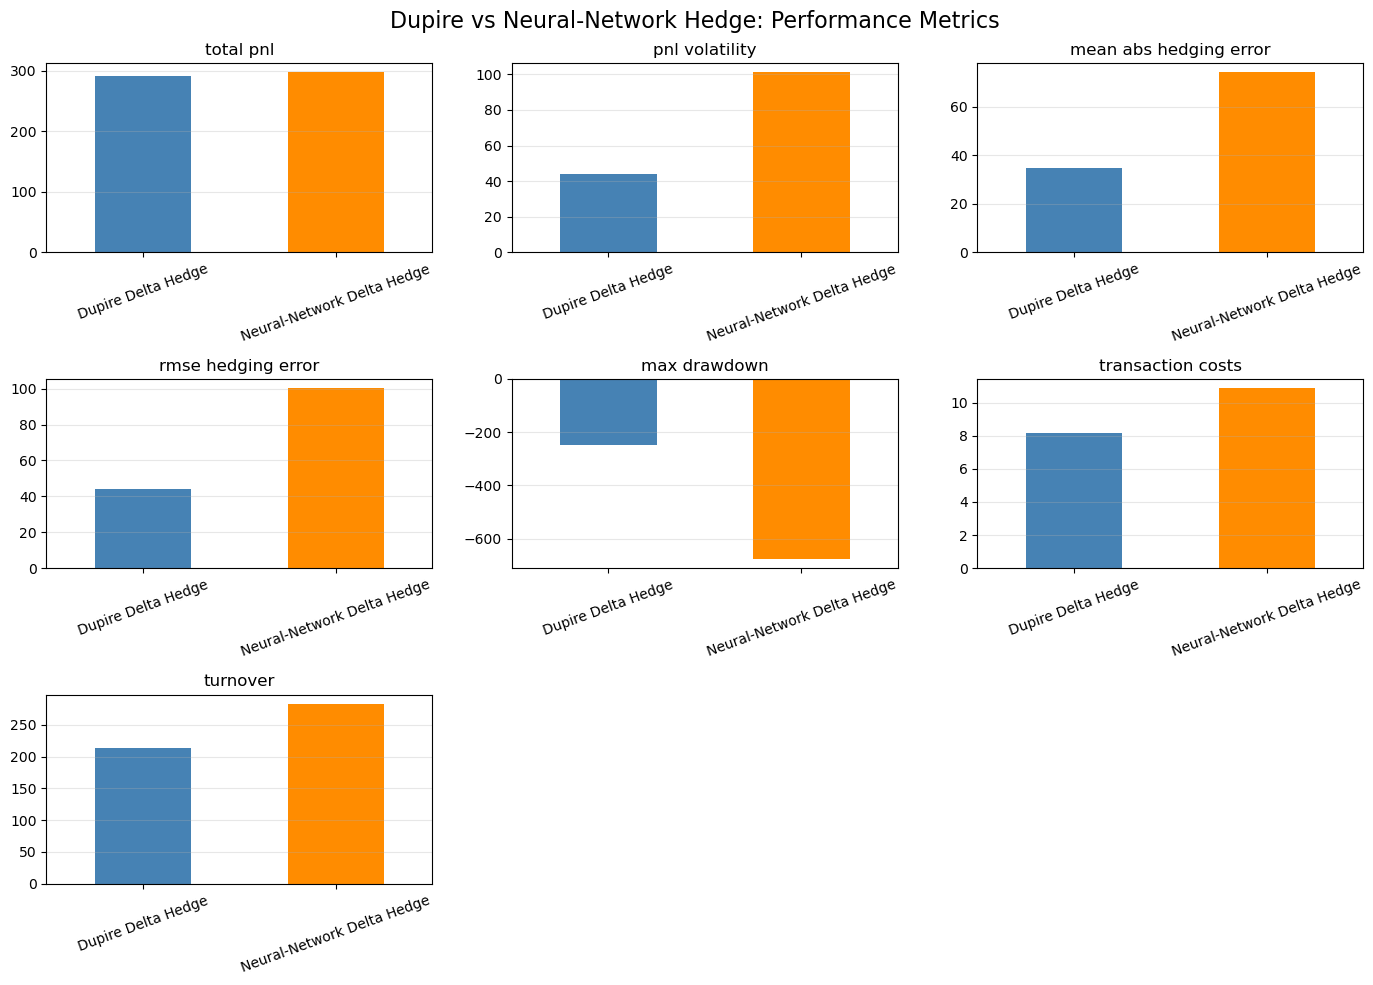

,model,total_pnl,pnl_volatility,mean_abs_hedging_error,rmse_hedging_error,max_drawdown,transaction_costs,turnover
0,Dupire Delta Hedge,291.240487,44.200036,34.605723,44.090859,-248.816277,8.168889,213.689847
1,Neural-Network Delta Hedge,297.334067,101.130588,74.183216,100.435705,-676.962017,10.895173,283.170938


In [9]:
# Plot key performance metrics to compare the two hedges
import matplotlib.pyplot as plt

metric_cols = [
    "total_pnl",
    "pnl_volatility",
    "mean_abs_hedging_error",
    "rmse_hedging_error",
    "max_drawdown",
    "transaction_costs",
    "turnover",
]

plot_df = comparison.set_index("model")[metric_cols].T

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, metric in zip(axes, metric_cols):
    values = comparison.set_index("model")[metric]
    values.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(metric_cols):]:
    ax.axis("off")

fig.suptitle("Dupire vs Neural-Network Hedge: Performance Metrics", fontsize=16)
plt.tight_layout()
plt.show()

# For most risk/error metrics, lower is better. For total_pnl and Sharpe, higher is better.
display(comparison[["model"] + metric_cols])


portfolio_value.png


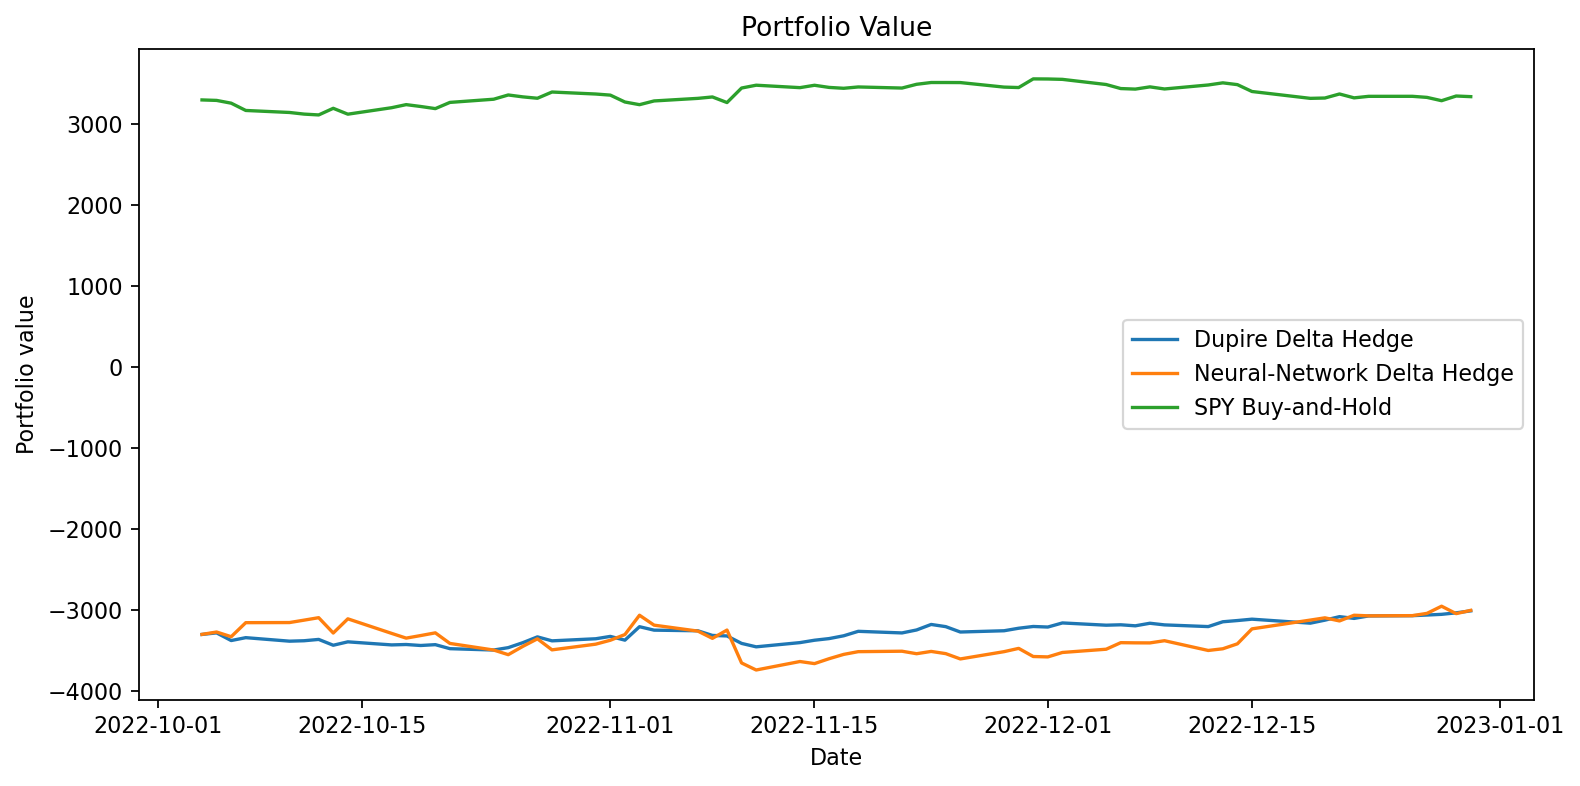

cumulative_pnl.png


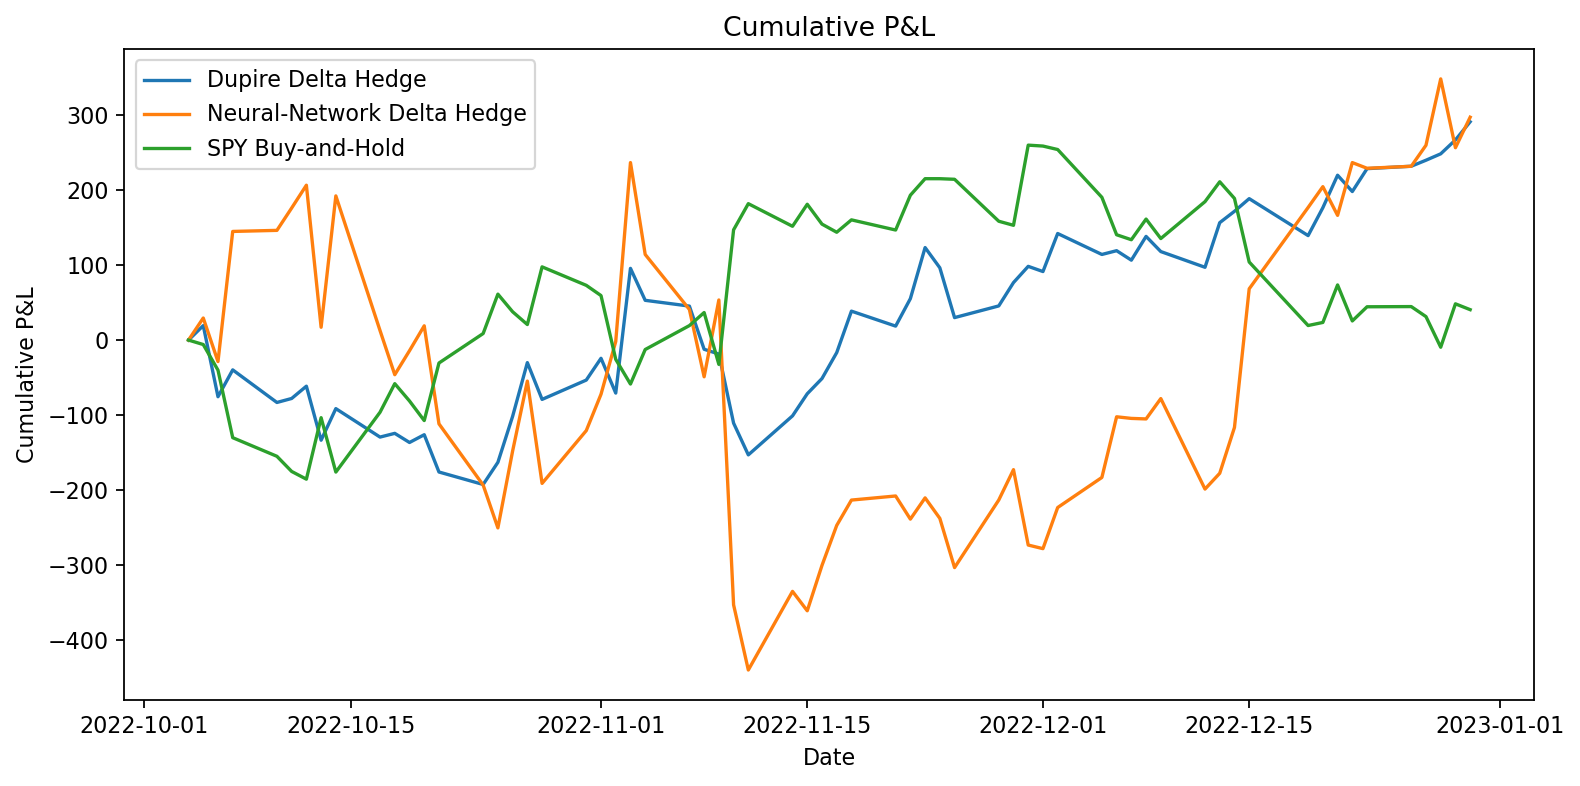

daily_hedging_error.png


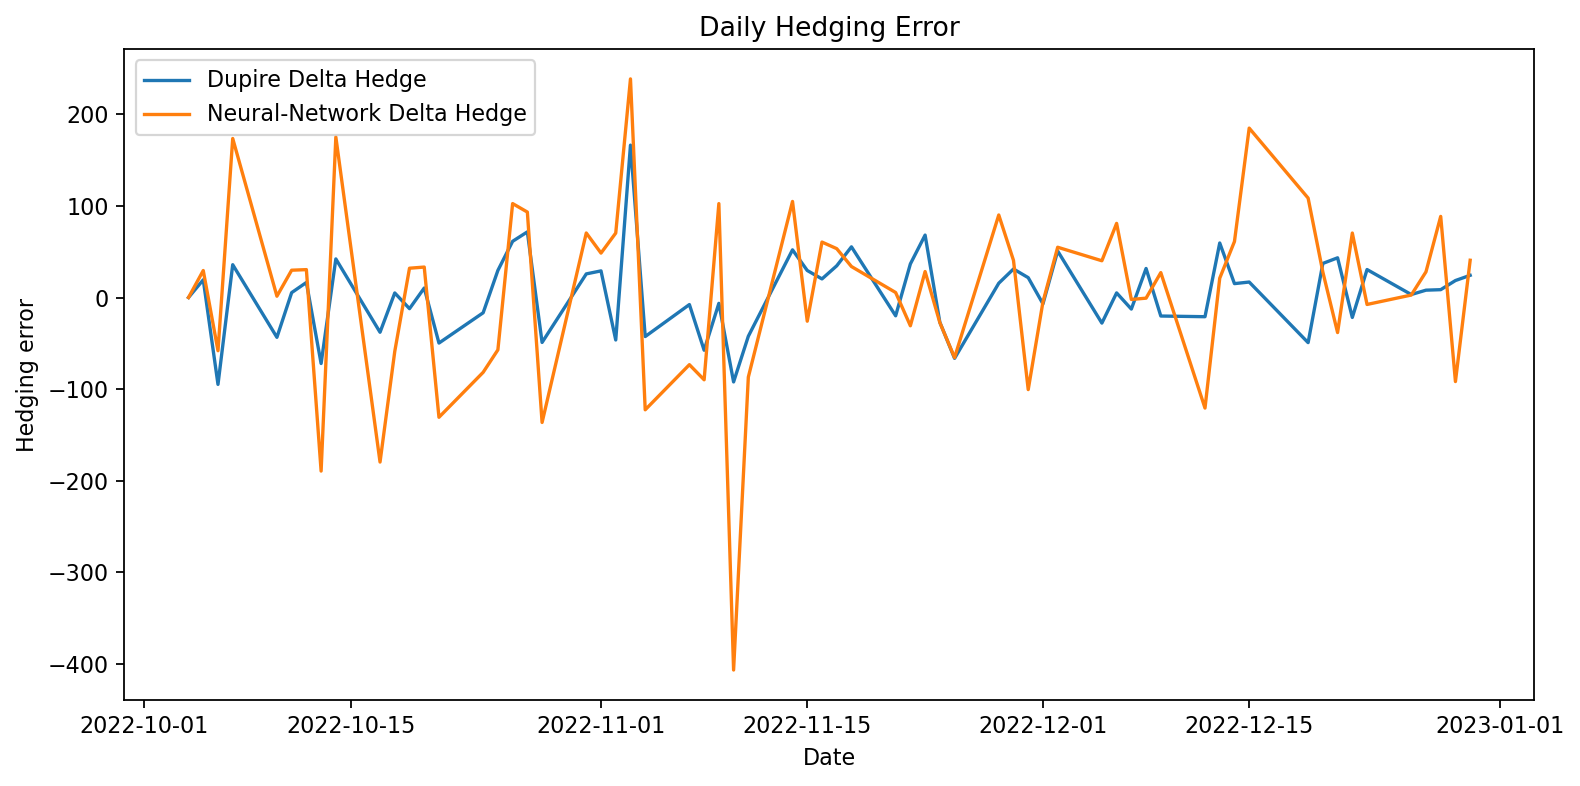

hedging_error_histogram.png


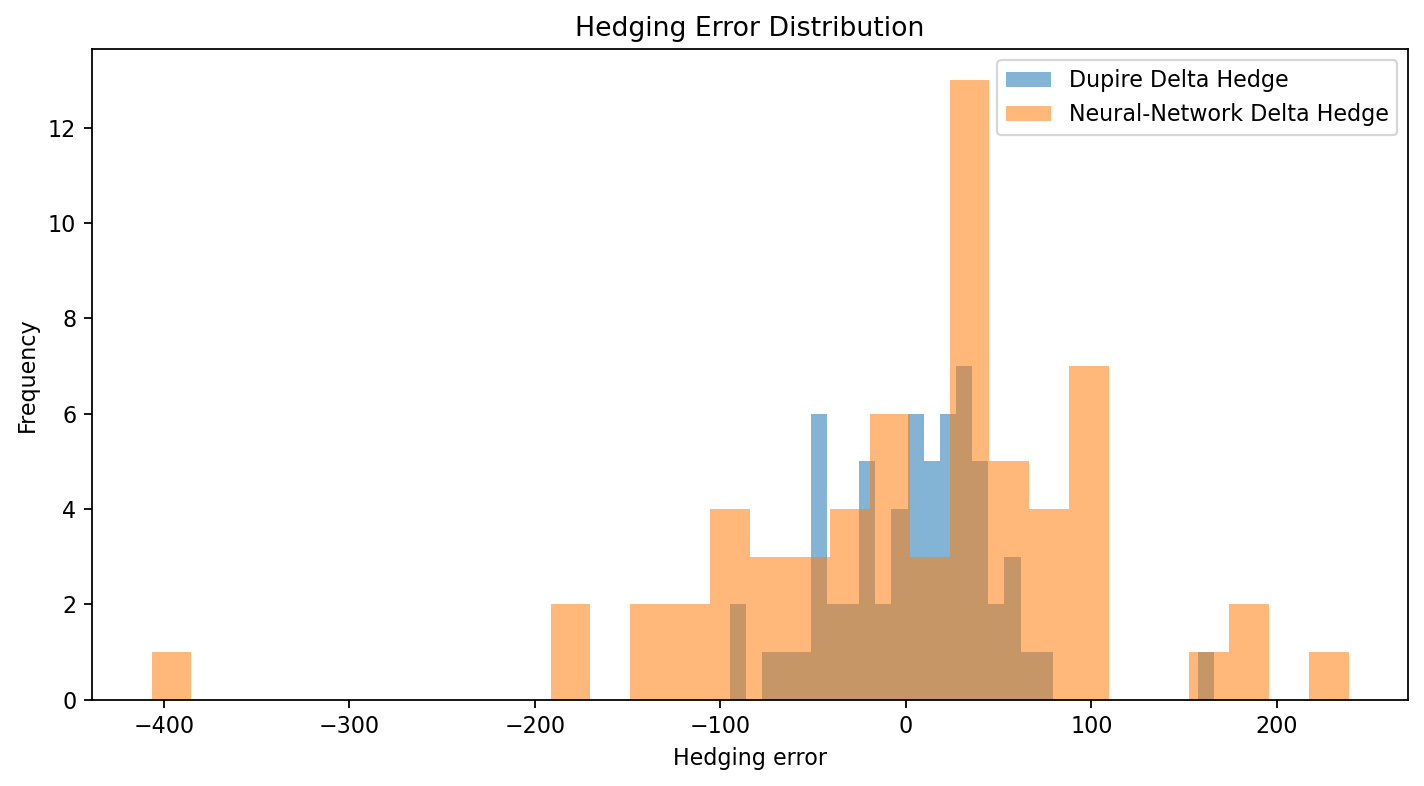

stock_hedge_position.png


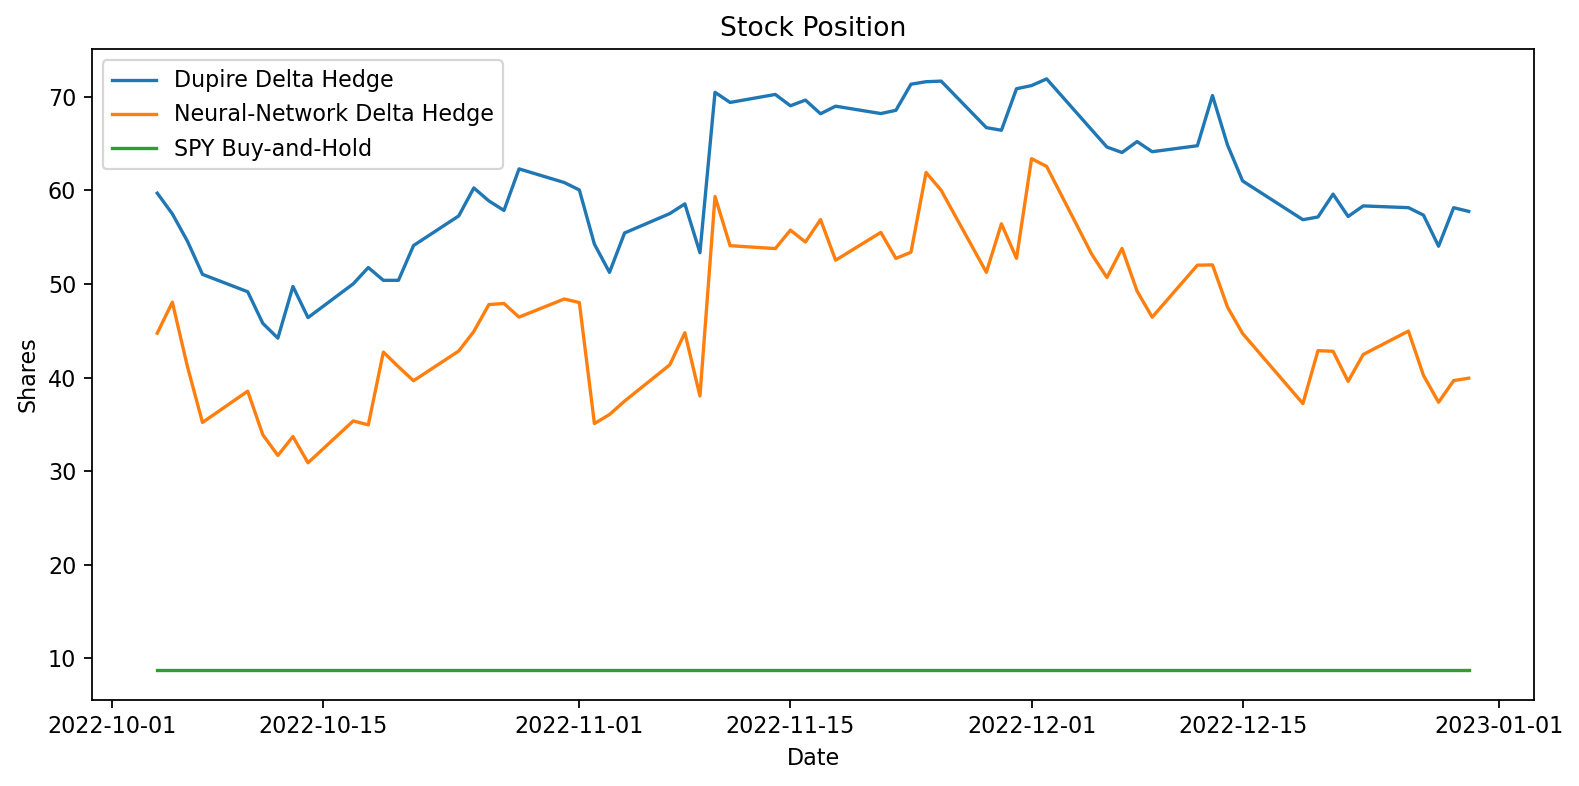

transaction_costs.png


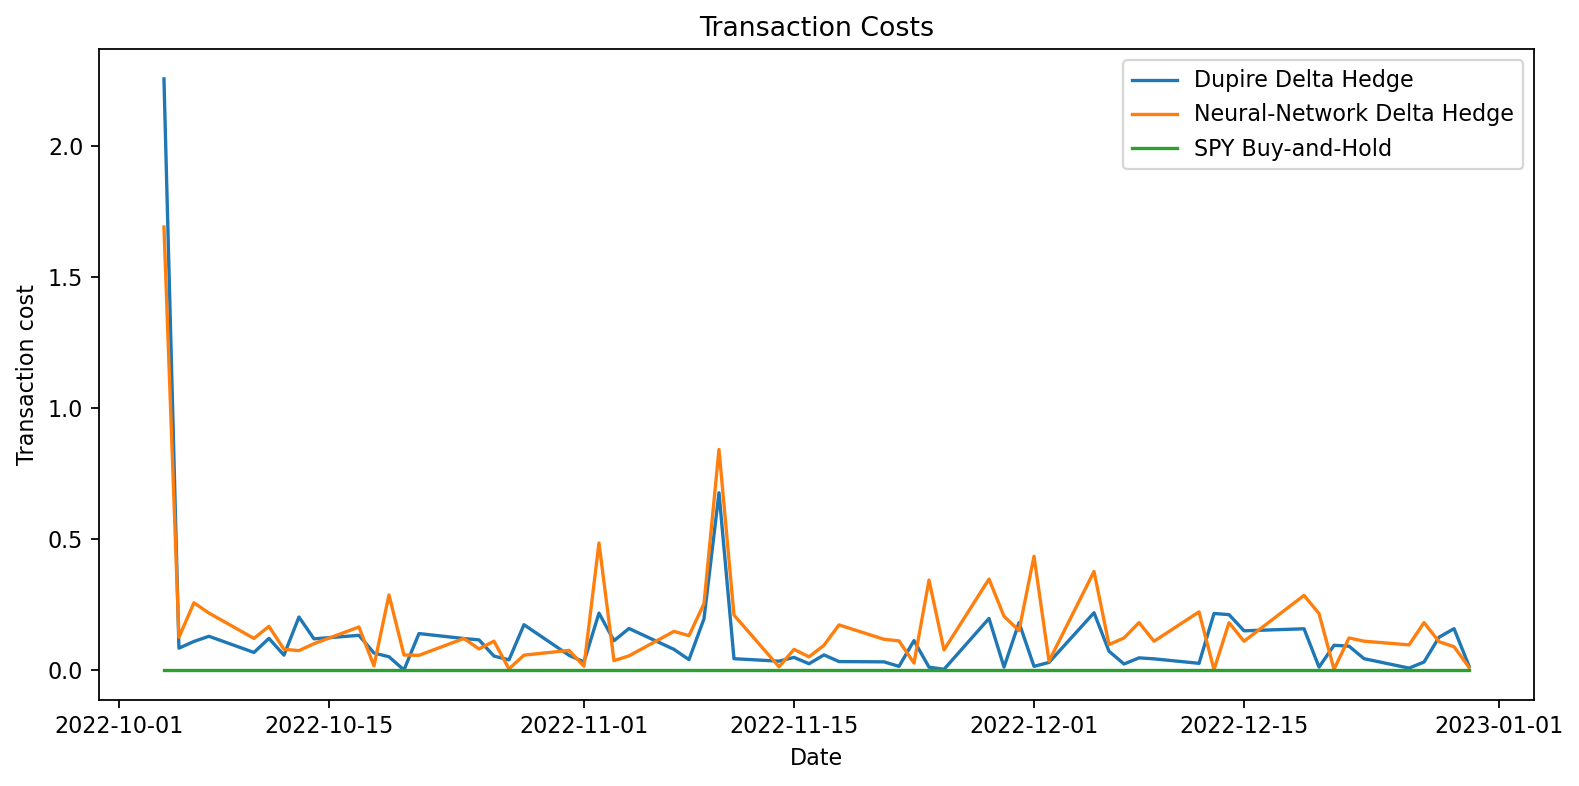

In [10]:
for plot_name in [
    "portfolio_value.png",
    "cumulative_pnl.png",
    "daily_hedging_error.png",
    "hedging_error_histogram.png",
    "stock_hedge_position.png",
    "transaction_costs.png",
]:
    print(plot_name)
    display(Image(filename=str(Path("results/plots") / plot_name)))

## Interpretation

- Lower mean absolute hedging error and RMSE hedging error indicate a more effective hedge.
- Lower turnover and transaction costs indicate a cheaper hedge to maintain.
- The NN should be judged only on the held-out period.
- Synthetic-backtest results demonstrate the pipeline, not live-market performance.
- Better hedging does not necessarily imply a profitable trading strategy.

<Axes: title={'center': 'Overall Normalized Hedge Performance Score'}, xlabel='model', ylabel='Score: higher is better'>

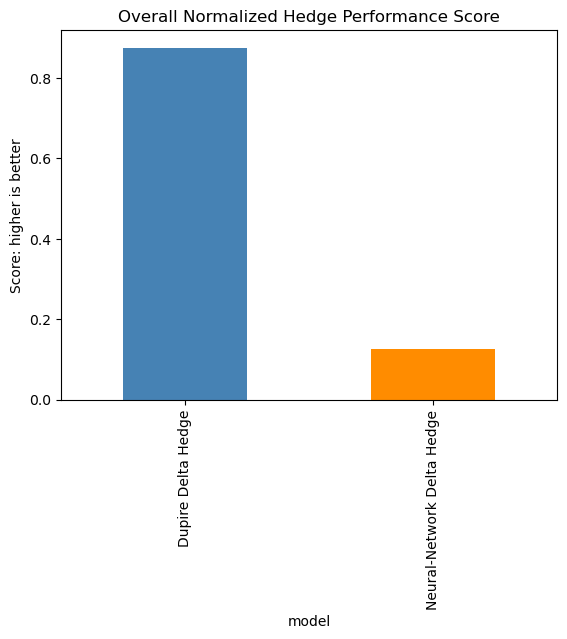

In [11]:
score_metrics = {
    "total_pnl": "higher",
    "sharpe": "higher",
    "pnl_volatility": "lower",
    "mean_abs_hedging_error": "lower",
    "rmse_hedging_error": "lower",
    "max_drawdown": "higher",   # closer to zero is better
    "transaction_costs": "lower",
    "turnover": "lower",
}

scores = comparison[["model"]].copy()

for metric, direction in score_metrics.items():
    x = comparison[metric]

    if x.max() == x.min():
        scores[metric] = 1.0
    elif direction == "higher":
        scores[metric] = (x - x.min()) / (x.max() - x.min())
    else:
        scores[metric] = (x.max() - x) / (x.max() - x.min())

scores["overall_score"] = scores[list(score_metrics.keys())].mean(axis=1)

scores.plot(
    x="model",
    y="overall_score",
    kind="bar",
    legend=False,
    title="Overall Normalized Hedge Performance Score",
    ylabel="Score: higher is better",
    color=["steelblue", "darkorange"],
)

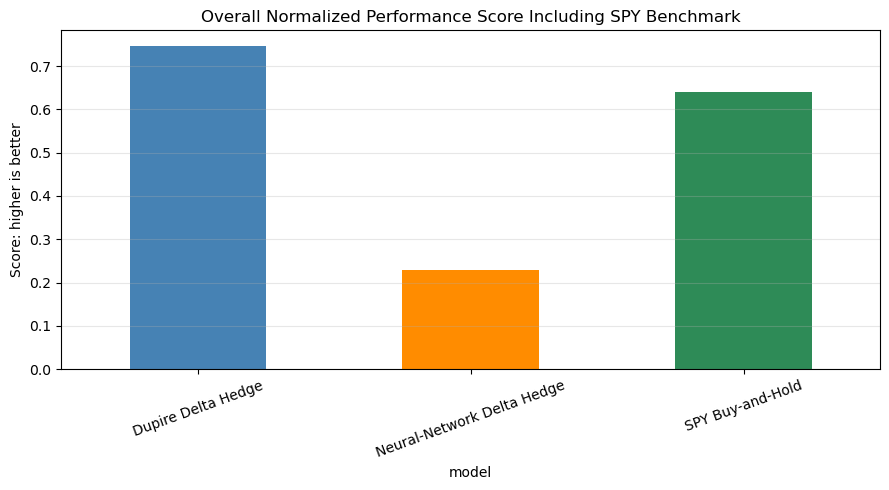

,model,total_pnl,sharpe,pnl_volatility,max_drawdown,transaction_costs,turnover
0,Dupire Delta Hedge,291.240487,1.660309,44.200036,-248.816277,8.168889,213.689847
1,Neural-Network Delta Hedge,297.334067,0.740836,101.130588,-676.962017,10.895173,283.170938
2,SPY Buy-and-Hold,40.575503,0.203814,50.163729,-269.599733,0.000000,0.000000


In [12]:
# Add SPY buy-and-hold as a market benchmark in the overall score plot
# Note: SPY is a market benchmark, not a short-call hedging strategy.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

spy_prices = dupire_result[["date", "stock_price"]].dropna().copy()
spy_prices = spy_prices.sort_values("date")
spy_initial_value = abs(dupire_result["portfolio_value"].iloc[0])
spy_shares = spy_initial_value / spy_prices["stock_price"].iloc[0]
spy_values = spy_shares * spy_prices["stock_price"]
spy_daily_pnl = spy_values.diff().fillna(0)
spy_cumulative_pnl = spy_values - spy_values.iloc[0]
spy_drawdown = spy_values - spy_values.cummax()

spy_row = {
    "model": "SPY Buy-and-Hold",
    "final_value": spy_values.iloc[-1],
    "total_pnl": spy_cumulative_pnl.iloc[-1],
    "mean_daily_pnl": spy_daily_pnl.mean(),
    "pnl_volatility": spy_daily_pnl.std(),
    "sharpe": np.sqrt(252) * spy_daily_pnl.mean() / spy_daily_pnl.std(),
    "mean_abs_hedging_error": np.nan,
    "rmse_hedging_error": np.nan,
    "max_drawdown": spy_drawdown.min(),
    "transaction_costs": 0.0,
    "turnover": 0.0,
}

comparison_with_spy = pd.concat(
    [comparison, pd.DataFrame([spy_row])],
    ignore_index=True,
)

benchmark_score_metrics = {
    "total_pnl": "higher",
    "sharpe": "higher",
    "pnl_volatility": "lower",
    "max_drawdown": "higher",
    "transaction_costs": "lower",
    "turnover": "lower",
}

benchmark_scores = comparison_with_spy[["model"]].copy()

for metric, direction in benchmark_score_metrics.items():
    x = comparison_with_spy[metric]

    if x.max() == x.min():
        benchmark_scores[metric] = 1.0
    elif direction == "higher":
        benchmark_scores[metric] = (x - x.min()) / (x.max() - x.min())
    else:
        benchmark_scores[metric] = (x.max() - x) / (x.max() - x.min())

benchmark_scores["overall_score"] = benchmark_scores[list(benchmark_score_metrics.keys())].mean(axis=1)

ax = benchmark_scores.plot(
    x="model",
    y="overall_score",
    kind="bar",
    legend=False,
    title="Overall Normalized Performance Score Including SPY Benchmark",
    ylabel="Score: higher is better",
    color=["steelblue", "darkorange", "seagreen"],
    figsize=(9, 5),
)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(comparison_with_spy[["model", "total_pnl", "sharpe", "pnl_volatility", "max_drawdown", "transaction_costs", "turnover"]])
